In [40]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt


In [41]:
df = pd.read_csv("Diwali Sales Data.csv",encoding='latin1')
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [42]:
df.shape

(11251, 15)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [44]:
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(8)

In [46]:
df = df.drop_duplicates()

In [47]:
df = df.drop(["User_ID" , "Status" , "unnamed1"] , axis = 1)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11243 entries, 0 to 11250
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Cust_name         11243 non-null  object 
 1   Product_ID        11243 non-null  object 
 2   Gender            11243 non-null  object 
 3   Age Group         11243 non-null  object 
 4   Age               11243 non-null  int64  
 5   Marital_Status    11243 non-null  int64  
 6   State             11243 non-null  object 
 7   Zone              11243 non-null  object 
 8   Occupation        11243 non-null  object 
 9   Product_Category  11243 non-null  object 
 10  Orders            11243 non-null  int64  
 11  Amount            11231 non-null  float64
dtypes: float64(1), int64(3), object(8)
memory usage: 1.1+ MB


In [49]:
df

,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11246,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0


In [50]:
df['is_female'] = df['Gender'].map({'F':1 , "M":0})

In [51]:
df = df.drop("Gender" , axis = 1)
df.head()


,Cust_name,Product_ID,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,is_female
0,Sanskriti,P00125942,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,1
1,Kartik,P00110942,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,1
2,Bindu,P00118542,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,1
3,Sudevi,P00237842,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,0
4,Joni,P00057942,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,0


In [52]:
df.dropna(subset=['Amount'] , inplace = True)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11231 entries, 0 to 11250
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Cust_name         11231 non-null  object 
 1   Product_ID        11231 non-null  object 
 2   Age Group         11231 non-null  object 
 3   Age               11231 non-null  int64  
 4   Marital_Status    11231 non-null  int64  
 5   State             11231 non-null  object 
 6   Zone              11231 non-null  object 
 7   Occupation        11231 non-null  object 
 8   Product_Category  11231 non-null  object 
 9   Orders            11231 non-null  int64  
 10  Amount            11231 non-null  float64
 11  is_female         11231 non-null  int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 1.1+ MB


In [54]:
df = df.drop(columns=["Cust_name"])
df.head()

,Product_ID,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,is_female
0,P00125942,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,1
1,P00110942,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,1
2,P00118542,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,1
3,P00237842,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,0
4,P00057942,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,0


In [55]:
df.describe()

,Age,Marital_Status,Orders,Amount,is_female
count,11231.000000,11231.000000,11231.000000,11231.000000,11231.000000
mean,35.411985,0.419998,2.489093,9454.084982,0.696999
std,12.756116,0.493580,1.114880,5221.728776,0.459576
min,12.000000,0.000000,1.000000,188.000000,0.000000
25%,27.000000,0.000000,2.000000,5443.000000,0.000000
50%,33.000000,0.000000,2.000000,8109.000000,1.000000
75%,43.000000,1.000000,3.000000,12677.500000,1.000000
max,92.000000,1.000000,4.000000,23952.000000,1.000000


EDA

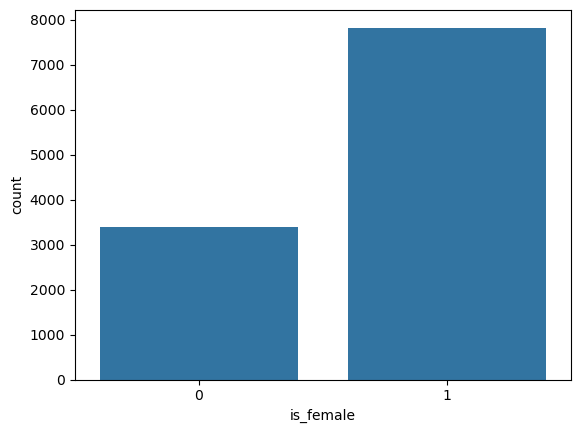

In [56]:
#Gender analysis:
sns.countplot(df , x = "is_female")
plt.show()

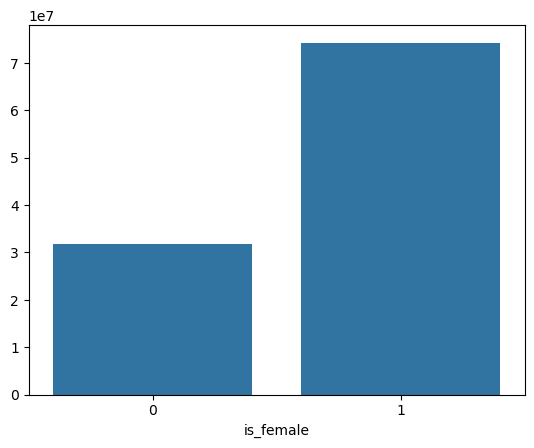

In [57]:
sales_gender = df.groupby("is_female")['Amount'].sum().sort_values(ascending=False)

sns.barplot(x = sales_gender.index , y = sales_gender.values)
plt.show()

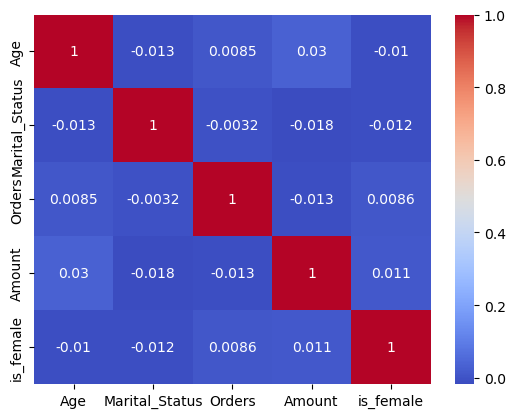

In [58]:
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr() , annot=True , cmap="coolwarm")

plt.show()